In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from src.utils import compute_individual_expectation_values, build_hva_layers, build_sparse_hamiltonian,find_best_initial_params,test_energy_consistency,optimize_energy

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2, FakeAthensV2

from matplotlib import pyplot as plt
import sys
import numpy as np
from qiskit.quantum_info import Pauli, Statevector
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.visualization import plot_gate_map
from qiskit.transpiler import CouplingMap

import pickle
import pandas as pd
import dill
"""with open("WS_TestFramework_realBackend.dill", "rb") as f:
    globals().update(dill.load(f))"""

sys.path.append("../../pauli_lindblad_per/")
from tomography.experiment import SparsePauliTomographyExperiment as tomography

plt.style.use("ggplot")

In [2]:
coupling = CouplingMap(couplinglist=[(0, 1), (1, 2), (1,0),(2,1)])
backend = GenericBackendV2(num_qubits=3, coupling_map=coupling)


hx = 1
hz = 1
J= -1
H_sparse = build_sparse_hamiltonian(hx, hz, backend, J=J)
best_guess, energy_exact = find_best_initial_params(H_sparse, backend)
opt_params, min_error = optimize_energy(best_guess, H_sparse, backend, energy_exact)
expectation_values, paulis = compute_individual_expectation_values(opt_params, backend, hx, hz,J=J, num_layers=1)
test_energy_consistency(opt_params, backend, hx, hz, J=-1)

Relativer Fehler      : 1.69e-16


In [3]:
params = [1,1,1]
expectation_values, paulis = compute_individual_expectation_values(params, backend, hx, hz,J=J, num_layers=1)
pauli_list = paulis
print(pauli_list)

['IIX', 'IIZ', 'IXI', 'IZI', 'XII', 'ZII', 'IZZ', 'ZZI']


In [4]:
df = pd.DataFrame({
    'Pauli': paulis,
    'Expectation Value': expectation_values
})
df

,Pauli,Expectation Value
0,IIX,0.021036
1,IIZ,0.708073
2,IXI,-0.326807
3,IZI,0.708073
4,XII,0.021036
5,ZII,0.708073
6,IZZ,0.501368
7,ZZI,0.501368


In [5]:
inst_map = [0,1,2]
qc = build_hva_layers(params, backend, qubit_indices=inst_map, num_layers=1)

qc.draw()

┌───┐┌───────┐┌───────┐                                      
q_0: ┤ H ├┤ Rz(1) ├┤ Rx(1) ├──■─────────────■─────────────────────
     ├───┤├───────┤├───────┤┌─┴─┐┌───────┐┌─┴─┐                   
q_1: ┤ H ├┤ Rz(1) ├┤ Rx(1) ├┤ X ├┤ Rz(1) ├┤ X ├──■─────────────■──
     ├───┤├───────┤├───────┤└───┘└───────┘└───┘┌─┴─┐┌───────┐┌─┴─┐
q_2: ┤ H ├┤ Rz(1) ├┤ Rx(1) ├───────────────────┤ X ├┤ Rz(1) ├┤ X ├
     └───┘└───────┘└───────┘                   └───┘└───────┘└───┘

In [6]:
# --- 5. Simulator instanziieren ---
backend = FakeWashingtonV2()
noise_model = NoiseModel.from_backend(backend)
simulator = AerSimulator(noise_model=noise_model)


In [7]:
experiment = tomography(
    circuits = [qc], #list of circuits from which to get the layers requiring tomography
    inst_map = inst_map, #which physical qubits on the processor to map the qubits in the circuit
    backend = backend, #quantum backend
    used_qubits= inst_map
    )

experiment.generate(
    samples = 100, #Number of samples to take from the fidelity pair measurements
    single_samples = 250, #samples to take from the pair-breaking measurements
    depths = [2,4,16,32,64] #values of 2n to make the pair measurements. Numbers must be even and non-zero
    )

shots = 1024
def executor(circuits):
    return backend.run(circuits, shots = shots, noise_model=noise_model).result().get_counts()

#run the experiment
experiment.run(executor)
noisedataframe = experiment.analyze()

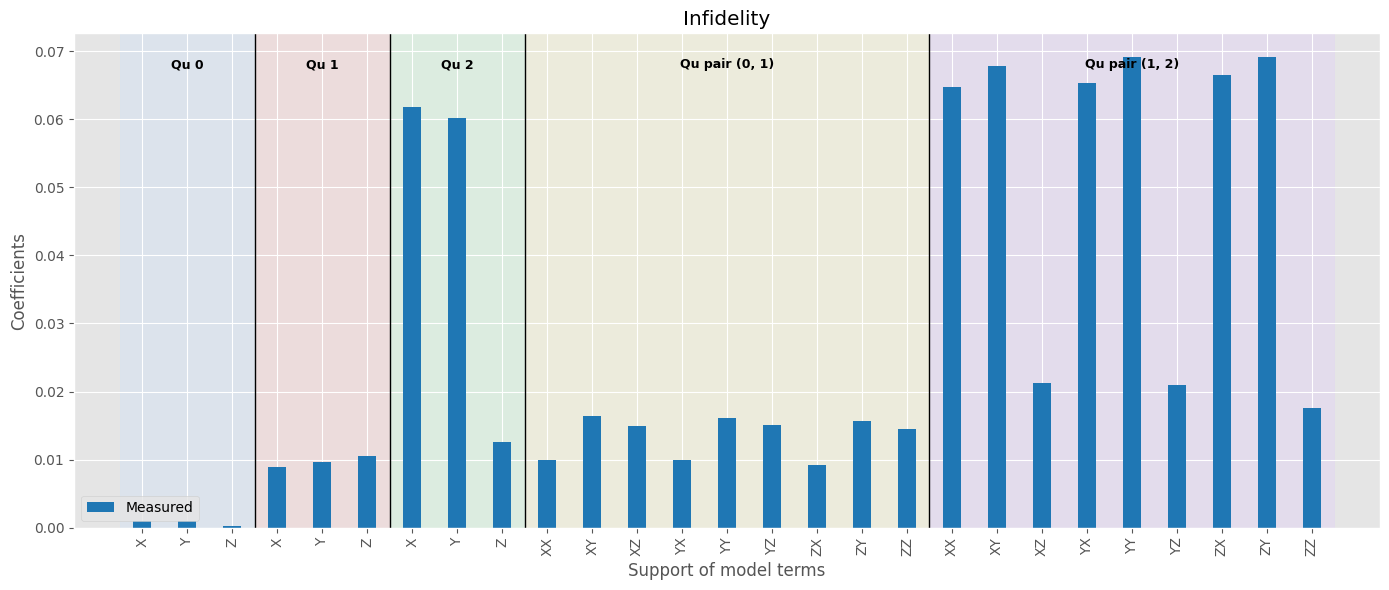

In [8]:
layer1 = experiment.analysis.get_layer_data(0)
layer1.plot_infidelitites(plot_style = 2)

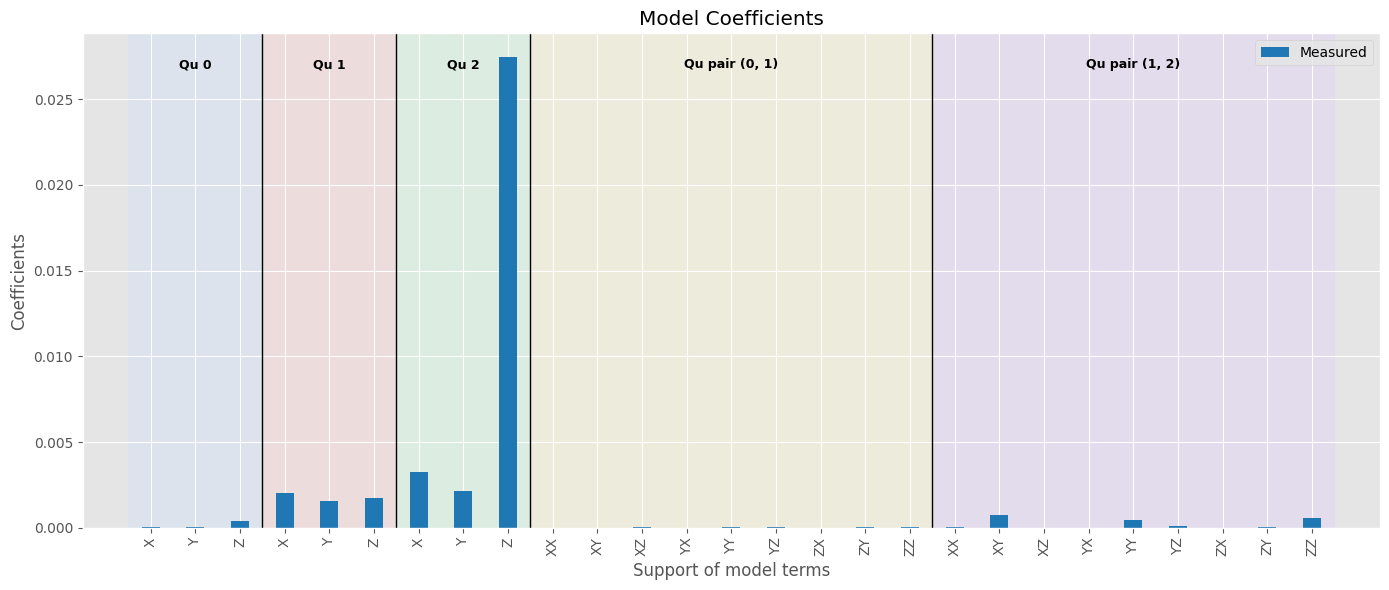

In [9]:
layer1.plot_coeffs(plot_style = 2)

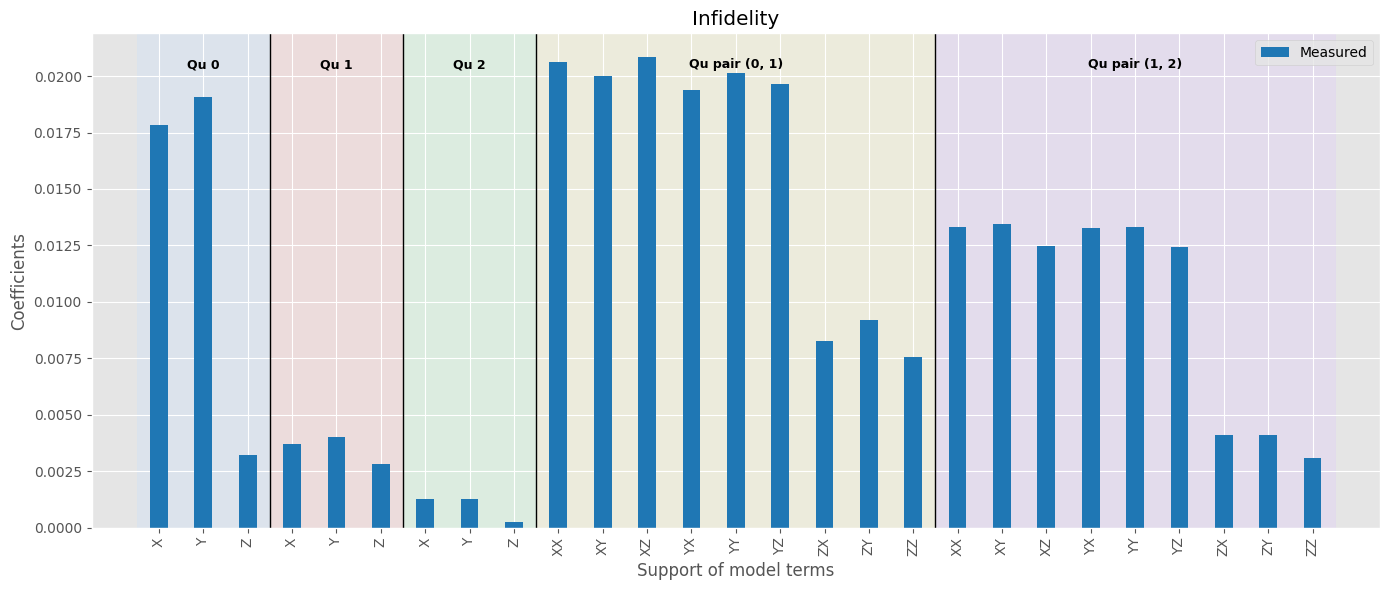

In [10]:
layer2 = experiment.analysis.get_layer_data(1)
layer2.plot_infidelitites(plot_style = 2)

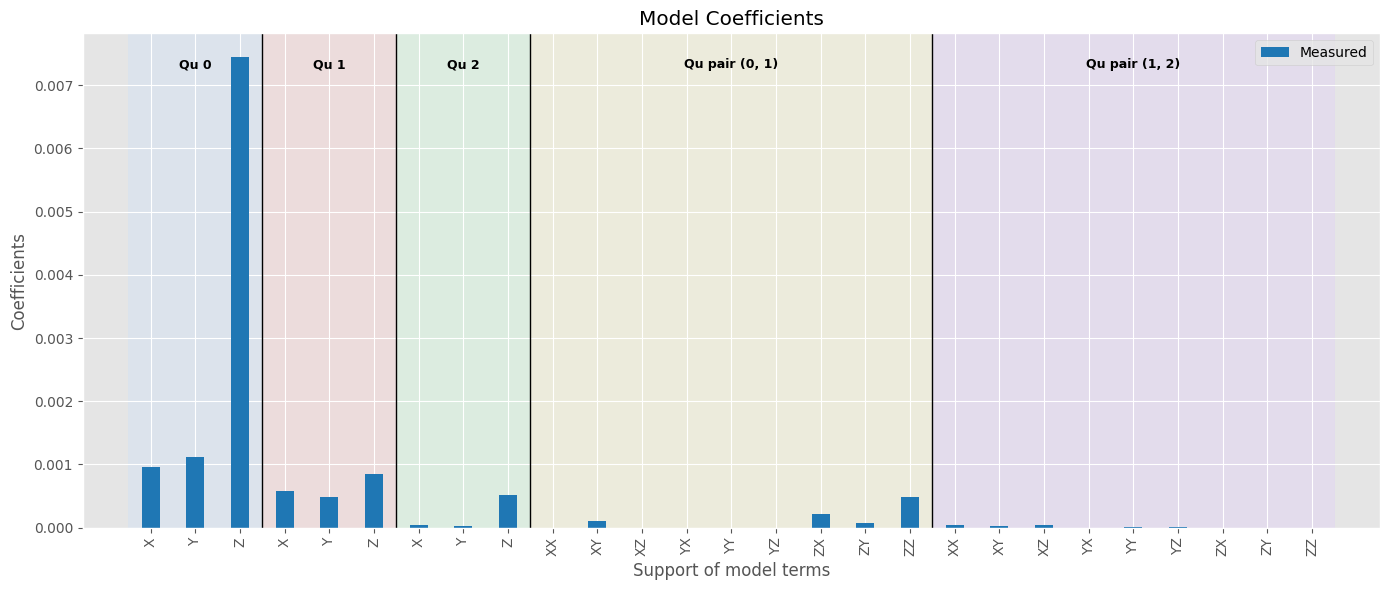

In [11]:
layer2.plot_coeffs(plot_style = 2)

In [12]:
# 2. PER-Experiment Setup
perexp = experiment.create_per_experiment([qc])

perexp.generate(
    expectations=pauli_list,
    samples=1000,
    noise_strengths=[0, 1, 2]
)

# 3. Ausführen
perexp.run(executor)

Aus SV-Simulation:  0.7080734182735712


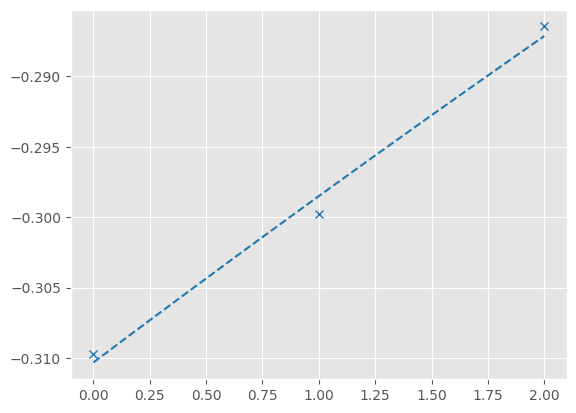

In [13]:
# 4. Analysieren
per_results = perexp.analyze()
result_1 = per_results[0].get_result(pauli_list[2]).plot()
print("Aus SV-Simulation: ",expectation_values[1])

In [14]:
# Compare absolute vs relative errors
for k in range(len(pauli_list)):
    exact = expectation_values[k]
    calc = per_results[0].get_result(pauli_list[k]).get_expectations()[0]
    abs_error = abs(exact - calc)
    rel_error = abs_error / abs(exact) if exact != 0 else float('inf')
    
    print(f"{pauli_list[k]}: Exact={exact:.4f}, Calc={calc:.4f}")
    print(f"  Absolute error: {abs_error:.6f}")
    print(f"  Relative error: {rel_error*100:.2f}%")
    print()

IIX: Exact=0.0210, Calc=0.0165
  Absolute error: 0.004489
  Relative error: 21.34%

IIZ: Exact=0.7081, Calc=0.6889
  Absolute error: 0.019163
  Relative error: 2.71%

IXI: Exact=-0.3268, Calc=-0.3097
  Absolute error: 0.017118
  Relative error: 5.24%

IZI: Exact=0.7081, Calc=0.6932
  Absolute error: 0.014880
  Relative error: 2.10%

XII: Exact=0.0210, Calc=0.0227
  Absolute error: 0.001651
  Relative error: 7.85%

ZII: Exact=0.7081, Calc=0.7007
  Absolute error: 0.007364
  Relative error: 1.04%

IZZ: Exact=0.5014, Calc=0.4937
  Absolute error: 0.007685
  Relative error: 1.53%

ZZI: Exact=0.5014, Calc=0.4928
  Absolute error: 0.008563
  Relative error: 1.71%



In [ ]:
import dill

to_save = {
    'experiment': experiment,
    'noisedataframe': noisedataframe,
    'expectation_values': expectation_values,
    'backend': backend,
    'simulator': simulator,
    'pauli_list': pauli_list,
    'perexp': perexp
}

with open("WS_TestFramework_realNoisemodel.dill", "wb") as f:
    dill.dump(to_save, f)